# NB07 — Phase 1B Bacteroidota PUL Hypothesis Test + Control Validation

**Project**: Gene Function Ecological Agora — Innovation Atlas Across the Bacterial Tree  
**Phase**: 1B — pre-registered hypothesis test  
**Purpose**: Test the Phase 1B pre-registered hypothesis on the full Phase 1B atlas; validate controls (positive + negative) under the revised M2 criterion + M1 rank-stratified parents; compute raw paralog-count effect sizes per (rank, class) per HIGH 2.

## Phase 1B pre-registered hypothesis (RESEARCH_PLAN.md v2.3)

> **Bacteroidota → Innovator-Exchange (high Producer + high Participation) for PUL (polysaccharide-utilization-locus) UniRef50 clusters** (CAZymes — glycoside hydrolases / carbohydrate-binding modules / polysaccharide lyases).
>
> Falsification at q < 0.0125 (Bonferroni for 4 focal tests):
> - Bacteroidota producer z below atlas median for non-housekeeping UniRefs, OR
> - Bacteroidota consumer z below atlas median (i.e. clumped, no exchange signal)

## Control validation criteria (M2 revised + HIGH 1)

- **Negative controls** (ribosomal / tRNA-synth / RNAP core): producer CI upper ≤ 0.5 (M2 — dosage-constrained signature). Do NOT expect zero; expect negative z.
- **Positive intra-phylum HGT** (AMR + TCS HK): producer or consumer signal in clades with documented HGT history.
- **Positive cross-phylum HGT** (β-lactamase + class-I CRISPR-Cas — HIGH 1): consumer z near zero or positive at family→order rank (where intra-order HGT lives) or higher.
- **Natural expansion**: producer CI lower > 0 (positive control on null responsiveness, validated in Phase 1A).

## Inputs

- `data/p1b_full_species.tsv`
- `data/p1b_full_uniref50.tsv`
- `data/p1b_full_scores.parquet` — 1.29M (rank, clade, UniRef) producer + consumer z-scores

## Outputs

- `data/p1b_control_validation.tsv` — per-(rank, class) score summary
- `data/p1b_effect_sizes_per_rank_class.tsv` — HIGH 2: raw paralog effect sizes
- `data/p1b_bacteroidota_pul_test.tsv` — pre-registered hypothesis verdict
- `data/p1b_known_hgt_validation.tsv` — HIGH 1: β-lactamase + class-I CRISPR-Cas validation
- `data/p1b_atlas_diagnostics.json` — full diagnostics
- `figures/p1b_scores_by_class_per_rank.png`
- `figures/p1b_bacteroidota_pul_position.png`

## Setup + load

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT_ROOT = Path("/home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora")
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"

RANKS = ["genus", "family", "order", "class", "phylum"]
DEEP_RANKS = ["family", "order", "class", "phylum"]  # ≥ family per Phase 1B hypothesis

scores = pd.read_parquet(DATA_DIR / "p1b_full_scores.parquet")
species_df = pd.read_csv(DATA_DIR / "p1b_full_species.tsv", sep="\t")
uniref_df = pd.read_csv(DATA_DIR / "p1b_full_uniref50.tsv", sep="\t")

print(f"Scores:  {scores.shape}")
print(f"Species: {species_df.shape}")
print(f"UniRef:  {uniref_df.shape}")

diagnostics = {
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "n_scores": int(len(scores)),
}

Scores:  (1294615, 15)
Species: (18989, 24)
UniRef:  (100192, 12)


## Stage 1 — Control validation per (rank, control_class)

In [2]:
def ci95(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    n = len(arr)
    if n < 3:
        return (np.nan, np.nan, np.nan, n)
    m = arr.mean()
    sem = arr.std(ddof=1) / np.sqrt(n)
    ci = sem * stats.t.ppf(0.975, n - 1)
    return (m, m - ci, m + ci, n)

rows = []
for (rank, cls), sub in scores.groupby(["rank", "control_class"]):
    pmean, pl, ph, pn = ci95(sub["producer_z"].values)
    cmean, cl, ch, cn = ci95(sub["consumer_z_informative"].values)
    rows.append({
        "rank": rank, "control_class": cls,
        "n_producer": pn, "producer_mean": pmean, "producer_ci_low": pl, "producer_ci_high": ph,
        "n_consumer": cn, "consumer_mean": cmean, "consumer_ci_low": cl, "consumer_ci_high": ch,
    })
validation = pd.DataFrame(rows)

def m2_verdict(row):
    cls = row["control_class"]
    if cls in ("neg_ribosomal", "neg_trna_synth", "neg_rnap_core"):
        if row["n_producer"] < 3:
            return "insufficient_n"
        # M2: producer CI upper ≤ 0.5 (dosage-constrained, not strictly positive)
        return "PASS" if row["producer_ci_high"] <= 0.5 else "FAIL"
    elif cls == "natural_expansion":
        if row["n_producer"] < 3:
            return "insufficient_n"
        return "PASS" if row["producer_ci_low"] > 0 else "WEAK"
    elif cls in ("pos_amr", "pos_tcs_hk"):
        return "intra_phylum_HGT_informational"
    elif cls in ("pos_betalac", "pos_crispr_cas"):
        # HIGH 1: consumer z near 0 or positive at appropriate rank = passed
        if row["n_consumer"] < 3:
            return "insufficient_n"
        return "PASS_cross_phylum_HGT" if row["consumer_ci_high"] >= 0 else "FAIL_clumped"
    elif cls == "hyp_cazyme":
        return "hypothesis_target"
    return "n/a"

validation["verdict"] = validation.apply(m2_verdict, axis=1)
validation = validation.sort_values(["rank", "control_class"]).reset_index(drop=True)
validation.to_csv(DATA_DIR / "p1b_control_validation.tsv", sep="\t", index=False)
print(f"Wrote p1b_control_validation.tsv: {len(validation)} rows")
print()
print(validation[["rank", "control_class", "n_producer", "producer_mean", "n_consumer", "consumer_mean", "verdict"]].to_string(index=False, float_format="%.3f"))

Wrote p1b_control_validation.tsv: 50 rows

  rank     control_class  n_producer  producer_mean  n_consumer  consumer_mean                        verdict
 class        hyp_cazyme       12559         -0.102        2166         -2.021              hypothesis_target
 class natural_expansion       21874          0.770       12036         -1.835                           PASS
 class     neg_ribosomal       17932         -0.155        7983         -1.714                           PASS
 class     neg_rnap_core        6734         -0.153        3264         -2.669                           PASS
 class    neg_trna_synth       16323         -0.146        6260         -1.820                           PASS
 class              none       33750         -0.176        3327         -1.791                            n/a
 class           pos_amr        8224          0.045        4738         -1.586 intra_phylum_HGT_informational
 class       pos_betalac       11417         -0.154        1185         -2.21

## Stage 2 — HIGH 2: Raw paralog effect sizes per (rank, class)

In [3]:
rows = []
for (rank, cls), sub in scores.groupby(["rank", "control_class"]):
    if len(sub) < 3:
        continue
    obs_paralog_mean = sub["paralog_count"].mean()
    cohort_mean = sub["cohort_mean_paralog"].mean()
    cohort_std = sub["cohort_std_paralog"].mean()
    raw_diff = obs_paralog_mean - cohort_mean
    pct_above = (raw_diff / cohort_mean * 100) if cohort_mean > 0 else np.nan
    rows.append({
        "rank": rank, "control_class": cls, "n": len(sub),
        "obs_paralog_mean": round(obs_paralog_mean, 3),
        "cohort_mean_paralog": round(cohort_mean, 3),
        "raw_diff": round(raw_diff, 3),
        "raw_pct_above_cohort": round(pct_above, 1) if not np.isnan(pct_above) else np.nan,
        "cohort_std_paralog": round(cohort_std, 3),
        "producer_z_mean": round(sub["producer_z"].mean(), 3),
    })
effect_df = pd.DataFrame(rows).sort_values(["rank", "control_class"]).reset_index(drop=True)
effect_df.to_csv(DATA_DIR / "p1b_effect_sizes_per_rank_class.tsv", sep="\t", index=False)
print(f"Wrote p1b_effect_sizes_per_rank_class.tsv: {len(effect_df)} rows")
print()
print(effect_df.to_string(index=False))

Wrote p1b_effect_sizes_per_rank_class.tsv: 50 rows

  rank     control_class      n  obs_paralog_mean  cohort_mean_paralog  raw_diff  raw_pct_above_cohort  cohort_std_paralog  producer_z_mean
 class        hyp_cazyme  12559             1.120                1.222    -0.102                  -8.3               0.760           -0.102
 class natural_expansion  21874             1.947                1.255     0.692                  55.2               0.821            0.770
 class     neg_ribosomal  17932             1.054                1.179    -0.125                 -10.6               0.618           -0.155
 class     neg_rnap_core   6734             1.071                1.208    -0.137                 -11.4               0.700           -0.153
 class    neg_trna_synth  16323             1.067                1.195    -0.128                 -10.7               0.666           -0.146
 class              none  33750             1.080                1.246    -0.166                 -13.3      

## Stage 3 — HIGH 1: β-lactamase + class-I CRISPR-Cas validation

Pre-registered: these classes should show consumer z near 0 or positive (cross-phylum HGT signature) at coarser ranks where their cross-phylum dispersion lives. Specifically check: at order→class and class→phylum parent rank, β-lactamase should approach 0 (or positive).

In [4]:
high1_rows = []
for cls in ["pos_betalac", "pos_crispr_cas", "pos_amr", "pos_tcs_hk"]:
    for rank in RANKS:
        sub = scores[(scores["control_class"] == cls) & (scores["rank"] == rank)]
        cmean, cl, ch, cn = ci95(sub["consumer_z_informative"].values)
        pmean, pl, ph, pn = ci95(sub["producer_z"].values)
        if pn < 3 and cn < 3:
            continue
        high1_rows.append({
            "control_class": cls, "rank": rank,
            "n_producer": pn, "producer_mean": round(float(pmean) if not np.isnan(pmean) else np.nan, 3),
            "n_consumer": cn, "consumer_mean": round(float(cmean) if not np.isnan(cmean) else np.nan, 3),
            "consumer_ci_low": round(float(cl) if not np.isnan(cl) else np.nan, 3),
            "consumer_ci_high": round(float(ch) if not np.isnan(ch) else np.nan, 3),
            "interpretation": (
                "strong cross-phylum dispersion (positive z)" if (not np.isnan(cmean) and cmean > 0.5)
                else "approaching null (mild HGT signal)" if (not np.isnan(cmean) and cmean > -1)
                else "clumped (vertical or intra-parent)"
            ),
        })
high1_df = pd.DataFrame(high1_rows)
high1_df.to_csv(DATA_DIR / "p1b_known_hgt_validation.tsv", sep="\t", index=False)
print(f"Wrote p1b_known_hgt_validation.tsv: {len(high1_df)} rows")
print()
print(high1_df.to_string(index=False))

Wrote p1b_known_hgt_validation.tsv: 20 rows

 control_class   rank  n_producer  producer_mean  n_consumer  consumer_mean  consumer_ci_low  consumer_ci_high                     interpretation
   pos_betalac  genus       23814         -0.058       14980        -12.543          -12.645           -12.441 clumped (vertical or intra-parent)
   pos_betalac family       15771         -0.087        5945         -6.894           -7.028            -6.760 clumped (vertical or intra-parent)
   pos_betalac  order       13554         -0.113        3470         -4.291           -4.381            -4.202 clumped (vertical or intra-parent)
   pos_betalac  class       11417         -0.154        1185         -2.212           -2.348            -2.076 clumped (vertical or intra-parent)
   pos_betalac phylum       10981         -0.163           0            NaN              NaN               NaN clumped (vertical or intra-parent)
pos_crispr_cas  genus       12884         -0.077       10449        -10.344    

## Stage 4 — Bacteroidota PUL hypothesis test

Test: Bacteroidota CAZymes (control_class = `hyp_cazyme`) at family / order / class / phylum rank should show **high producer + high consumer z** (Innovator-Exchange = both above zero with 95% CI lower bound > 0).

In [5]:
# Build species → phylum lookup, then clade_id → phylum lookup at each rank
species_phylum = species_df.set_index("gtdb_species_clade_id")["phylum"].to_dict()

# At each rank, the clade_id is a label like "g__Bacteroides" (genus) / "f__Bacteroidaceae" (family) etc.
# Need to map clade_id → phylum. For genus rank, clade_id is the genus; we look up which phylum any species
# in that genus belongs to. For family rank, similar.

rank_to_phylum_map = {}
for rank in RANKS:
    if rank not in species_df.columns:
        continue
    if rank == "phylum":
        clade_to_phylum = {p: p for p in species_df["phylum"].dropna().unique()}
    else:
        clade_to_phylum = species_df[[rank, "phylum"]].drop_duplicates().set_index(rank)["phylum"].to_dict()
    rank_to_phylum_map[rank] = clade_to_phylum

# Tag each score row with its phylum
def get_phylum_for_clade(rank, clade_id):
    return rank_to_phylum_map.get(rank, {}).get(clade_id, None)

scores["clade_phylum"] = scores.apply(lambda r: get_phylum_for_clade(r["rank"], r["clade_id"]), axis=1)

# Bacteroidota hypothesis test on hyp_cazyme at deep ranks
BACTEROIDOTA = "p__Bacteroidota"

bact_rows = []
for rank in DEEP_RANKS:
    sub_bact = scores[
        (scores["rank"] == rank)
        & (scores["control_class"] == "hyp_cazyme")
        & (scores["clade_phylum"] == BACTEROIDOTA)
    ]
    sub_other = scores[
        (scores["rank"] == rank)
        & (scores["control_class"] == "hyp_cazyme")
        & (scores["clade_phylum"] != BACTEROIDOTA)
        & (scores["clade_phylum"].notna())
    ]
    pm_b, pl_b, ph_b, pn_b = ci95(sub_bact["producer_z"].values)
    cm_b, cl_b, ch_b, cn_b = ci95(sub_bact["consumer_z_informative"].values)
    pm_o, pl_o, ph_o, pn_o = ci95(sub_other["producer_z"].values)
    cm_o, cl_o, ch_o, cn_o = ci95(sub_other["consumer_z_informative"].values)

    # Pre-registered verdict: Bacteroidota Innovator-Exchange = both producer AND consumer 95% CI lower > 0
    producer_above_zero = (not np.isnan(pl_b)) and (pl_b > 0)
    consumer_above_zero = (not np.isnan(cl_b)) and (cl_b > 0)
    if pn_b < 3:
        verdict = "insufficient_n"
    elif producer_above_zero and consumer_above_zero:
        verdict = "INNOVATOR_EXCHANGE_SUPPORTED"
    elif producer_above_zero and not consumer_above_zero:
        verdict = "INNOVATOR_ISOLATED (producer high but participation not above null)"
    elif not producer_above_zero and consumer_above_zero:
        verdict = "BROKER (participation high but producer not above null)"
    else:
        verdict = "STABLE_OR_FALSIFIED"

    # Bonferroni-corrected α=0.0125 for 4 focal tests
    if pn_b >= 3 and pn_o >= 3:
        # Welch's t-test, one-tailed (Bacteroidota > others)
        t_p, p_p = stats.ttest_ind(
            sub_bact["producer_z"].dropna(), sub_other["producer_z"].dropna(),
            equal_var=False, alternative="greater"
        )
    else:
        t_p, p_p = np.nan, np.nan
    if cn_b >= 3 and cn_o >= 3:
        t_c, p_c = stats.ttest_ind(
            sub_bact["consumer_z_informative"].dropna(), sub_other["consumer_z_informative"].dropna(),
            equal_var=False, alternative="greater"
        )
    else:
        t_c, p_c = np.nan, np.nan

    bact_rows.append({
        "rank": rank,
        "bacteroidota_n_producer": pn_b, "bacteroidota_producer_mean": round(float(pm_b) if not np.isnan(pm_b) else np.nan, 3),
        "bacteroidota_producer_ci_low": round(float(pl_b) if not np.isnan(pl_b) else np.nan, 3),
        "bacteroidota_producer_ci_high": round(float(ph_b) if not np.isnan(ph_b) else np.nan, 3),
        "bacteroidota_n_consumer": cn_b, "bacteroidota_consumer_mean": round(float(cm_b) if not np.isnan(cm_b) else np.nan, 3),
        "bacteroidota_consumer_ci_low": round(float(cl_b) if not np.isnan(cl_b) else np.nan, 3),
        "bacteroidota_consumer_ci_high": round(float(ch_b) if not np.isnan(ch_b) else np.nan, 3),
        "other_phyla_producer_mean": round(float(pm_o) if not np.isnan(pm_o) else np.nan, 3),
        "other_phyla_consumer_mean": round(float(cm_o) if not np.isnan(cm_o) else np.nan, 3),
        "producer_t": round(float(t_p) if not np.isnan(t_p) else np.nan, 3),
        "producer_p_one_sided": float(p_p) if not np.isnan(p_p) else np.nan,
        "producer_passes_bonferroni": (p_p < 0.0125) if not np.isnan(p_p) else False,
        "consumer_t": round(float(t_c) if not np.isnan(t_c) else np.nan, 3),
        "consumer_p_one_sided": float(p_c) if not np.isnan(p_c) else np.nan,
        "consumer_passes_bonferroni": (p_c < 0.0125) if not np.isnan(p_c) else False,
        "verdict": verdict,
    })

bact_df = pd.DataFrame(bact_rows)
bact_df.to_csv(DATA_DIR / "p1b_bacteroidota_pul_test.tsv", sep="\t", index=False)
print(f"Wrote p1b_bacteroidota_pul_test.tsv: {len(bact_df)} rows")
print()
print(bact_df.to_string(index=False))

Wrote p1b_bacteroidota_pul_test.tsv: 4 rows

  rank  bacteroidota_n_producer  bacteroidota_producer_mean  bacteroidota_producer_ci_low  bacteroidota_producer_ci_high  bacteroidota_n_consumer  bacteroidota_consumer_mean  bacteroidota_consumer_ci_low  bacteroidota_consumer_ci_high  other_phyla_producer_mean  other_phyla_consumer_mean  producer_t  producer_p_one_sided  producer_passes_bonferroni  consumer_t  consumer_p_one_sided  consumer_passes_bonferroni             verdict
family                     3771                      -0.069                        -0.094                         -0.044                     2076                      -9.331                        -9.576                         -9.087                     -0.065                     -5.561      -0.258              0.601789                       False     -28.024              1.000000                       False STABLE_OR_FALSIFIED
 order                     2663                      -0.105                        -0.131

## Stage 5 — Atlas-level distributions visualization

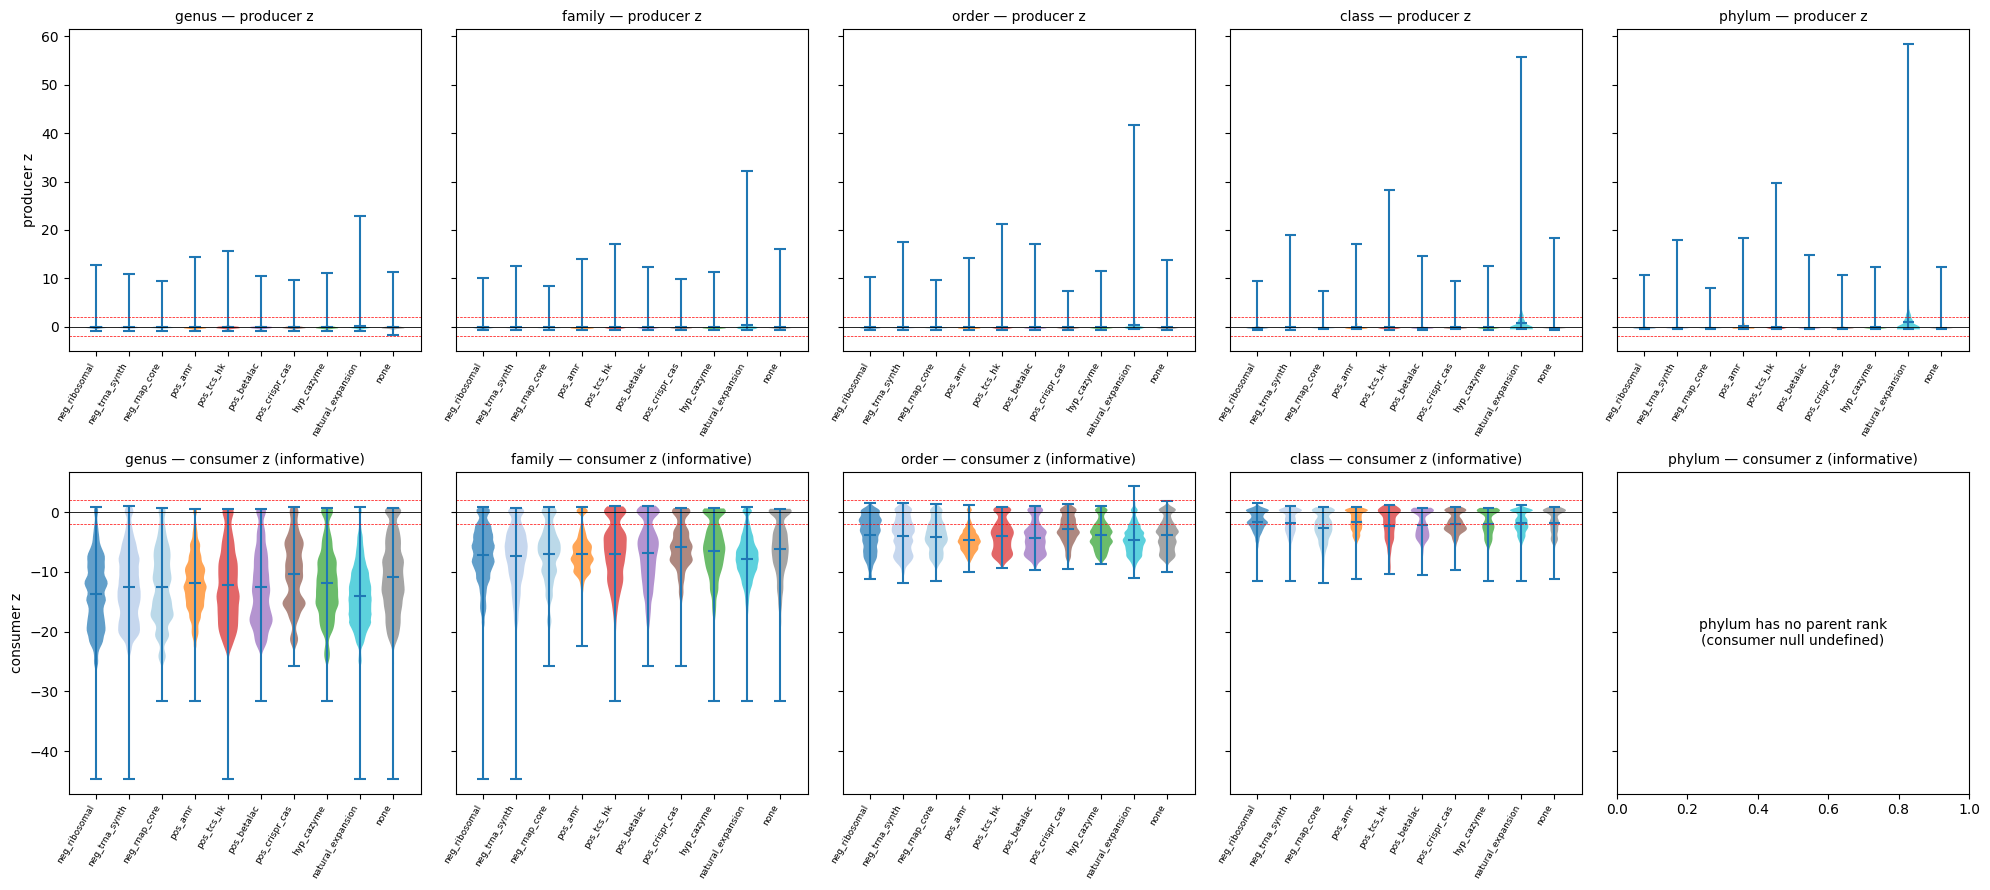

Saved figures/p1b_scores_by_class_per_rank.png


In [6]:
control_order = ["neg_ribosomal", "neg_trna_synth", "neg_rnap_core",
                 "pos_amr", "pos_tcs_hk", "pos_betalac", "pos_crispr_cas",
                 "hyp_cazyme", "natural_expansion", "none"]
control_colors = {
    "neg_ribosomal": "#1f77b4", "neg_trna_synth": "#aec7e8", "neg_rnap_core": "#9ecae1",
    "pos_amr": "#ff7f0e", "pos_tcs_hk": "#d62728",
    "pos_betalac": "#9467bd", "pos_crispr_cas": "#8c564b",
    "hyp_cazyme": "#2ca02c", "natural_expansion": "#17becf", "none": "#7f7f7f",
}

fig, axes = plt.subplots(2, len(RANKS), figsize=(4 * len(RANKS), 9), sharey="row")
for col, rank in enumerate(RANKS):
    sub = scores[scores["rank"] == rank]
    # Producer z
    ax = axes[0, col]
    data = [sub[sub["control_class"] == c]["producer_z"].dropna().values for c in control_order]
    pos = list(range(len(control_order)))
    parts = ax.violinplot([d if len(d) > 0 else [0] for d in data], positions=pos,
                          showmeans=True, showmedians=False, widths=0.7)
    for pc, c in zip(parts["bodies"], control_order):
        pc.set_facecolor(control_colors[c]); pc.set_alpha(0.7)
    ax.axhline(0, color="black", lw=0.6); ax.axhline(2, color="red", ls="--", lw=0.5); ax.axhline(-2, color="red", ls="--", lw=0.5)
    ax.set_xticks(pos); ax.set_xticklabels(control_order, rotation=60, ha="right", fontsize=6.5)
    ax.set_title(f"{rank} — producer z", fontsize=10)
    if col == 0:
        ax.set_ylabel("producer z")
    # Consumer z (informative)
    ax = axes[1, col]
    if rank == "phylum":
        ax.text(0.5, 0.5, "phylum has no parent rank\n(consumer null undefined)",
               ha="center", va="center", transform=ax.transAxes, fontsize=10)
    else:
        data_c = [sub[(sub["control_class"] == c) & (~sub["consumer_z_informative"].isna())]["consumer_z_informative"].values for c in control_order]
        parts = ax.violinplot([d if len(d) > 0 else [0] for d in data_c], positions=pos,
                              showmeans=True, showmedians=False, widths=0.7)
        for pc, c in zip(parts["bodies"], control_order):
            pc.set_facecolor(control_colors[c]); pc.set_alpha(0.7)
        ax.axhline(0, color="black", lw=0.6); ax.axhline(2, color="red", ls="--", lw=0.5); ax.axhline(-2, color="red", ls="--", lw=0.5)
        ax.set_xticks(pos); ax.set_xticklabels(control_order, rotation=60, ha="right", fontsize=6.5)
    ax.set_title(f"{rank} — consumer z (informative)", fontsize=10)
    if col == 0:
        ax.set_ylabel("consumer z")

plt.tight_layout()
plt.savefig(FIG_DIR / "p1b_scores_by_class_per_rank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/p1b_scores_by_class_per_rank.png")

/tmp/ipykernel_103130/1765038415.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc="upper left")


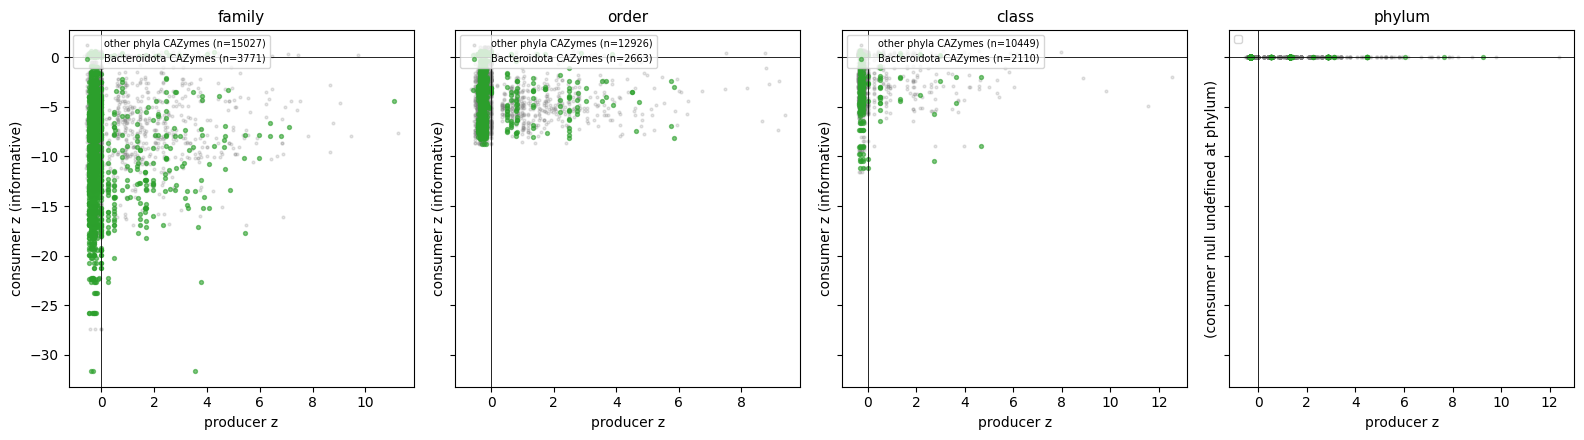

Saved figures/p1b_bacteroidota_pul_position.png


In [7]:
# Bacteroidota PUL position figure: Bacteroidota CAZymes vs other-phyla CAZymes per rank
fig, axes = plt.subplots(1, len(DEEP_RANKS), figsize=(4 * len(DEEP_RANKS), 4.5), sharey=True)
for ax, rank in zip(axes, DEEP_RANKS):
    sub_bact = scores[(scores["rank"] == rank) & (scores["control_class"] == "hyp_cazyme") & (scores["clade_phylum"] == BACTEROIDOTA)]
    sub_other = scores[(scores["rank"] == rank) & (scores["control_class"] == "hyp_cazyme") & (scores["clade_phylum"] != BACTEROIDOTA) & scores["clade_phylum"].notna()]
    if rank != "phylum":
        ax.scatter(sub_other["producer_z"], sub_other["consumer_z_informative"], s=4, alpha=0.2, color="gray", label=f"other phyla CAZymes (n={len(sub_other)})")
        ax.scatter(sub_bact["producer_z"], sub_bact["consumer_z_informative"], s=8, alpha=0.6, color="#2ca02c", label=f"Bacteroidota CAZymes (n={len(sub_bact)})")
        ax.set_ylabel("consumer z (informative)")
    else:
        ax.scatter(sub_other["producer_z"], np.zeros(len(sub_other)), s=4, alpha=0.2, color="gray")
        ax.scatter(sub_bact["producer_z"], np.zeros(len(sub_bact)), s=8, alpha=0.6, color="#2ca02c")
        ax.set_ylabel("(consumer null undefined at phylum)")
    ax.axvline(0, color="black", lw=0.6); ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("producer z")
    ax.set_title(f"{rank}", fontsize=11)
    ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "p1b_bacteroidota_pul_position.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/p1b_bacteroidota_pul_position.png")

In [8]:
# Materialize diagnostics
diagnostics["control_validation_summary"] = validation.to_dict(orient="records")
diagnostics["effect_sizes_summary"] = effect_df.to_dict(orient="records")
diagnostics["high1_known_hgt_validation"] = high1_df.to_dict(orient="records")
diagnostics["bacteroidota_pul_test"] = bact_df.to_dict(orient="records")
diagnostics["completed_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
with open(DATA_DIR / "p1b_atlas_diagnostics.json", "w") as f:
    json.dump(diagnostics, f, indent=2, default=str)
print("Wrote p1b_atlas_diagnostics.json")

Wrote p1b_atlas_diagnostics.json
